# Параметрическое исследование модели Росса

Анализ влияния числа работающих машин на надёжность системы
и загрузку ремонтной бригады.

In [1]:
using DrWatson
@quickactivate "project"
using ResumableFunctions
using ConcurrentSim
using Distributions
using StableRNGs
using DataFrames
using Statistics
using CSV
using Plots

╔═╡ Параметры эксперимента

In [2]:
RUNS = 10
machine_counts = [5, 10, 20, 30]
S = 3
repairers = 2
LAMBDA = 100.0
MU = 1.0

1.0

╔═╡ Аналитическая оценка времени до отказа

In [3]:
function analytical_estimate(N, S, λ, μ)
    λ_total = N / λ
    reserve_factor = S + 1
    return reserve_factor / max(λ_total - μ, 1e-6)
end

analytical_estimate (generic function with 1 method)

╔═╡ Процесс работы одной машины

In [4]:
@resumable function machine(
    env::Environment,
    repair_facility::Resource,
    spares::Store{Process},
    repair_queue_log,
    working_log,
    rng,
    F,
    G,
    N,
)
    while true
        try
            @yield timeout(env, Inf)
        catch
        end
        @yield timeout(env, rand(rng, F))
        current_working = N + length(spares.items) - 1
        push!(working_log, (now(env), current_working))
        get_spare = take!(spares)
        push!(repair_queue_log, (now(env), length(repair_facility.put_queue)))
        @yield get_spare | timeout(env)
        if state(get_spare) != ConcurrentSim.idle
            @yield interrupt(value(get_spare))
        else
            throw(StopSimulation("No more spares!"))
        end
        req = request(repair_facility)
        @yield req
        @yield timeout(env, rand(rng, G))
        @yield unlock(repair_facility)
        @yield put!(spares, active_process(env))
    end
end

machine (generic function with 1 method)

╔═╡ Инициализация системы

In [5]:
@resumable function start_sim(
    env::Environment,
    repair_facility::Resource,
    spares::Store{Process},
    repair_queue_log,
    working_log,
    rng,
    F,
    G,
    N,
    S,
)
    for i in 1:N
        proc = @process machine(env, repair_facility, spares, repair_queue_log, working_log, rng, F, G, N)
        @yield interrupt(proc)
    end
    for i in 1:S
        proc = @process machine(env, repair_facility, spares, repair_queue_log, working_log, rng, F, G, N)
        @yield put!(spares, proc)
    end
end

start_sim (generic function with 1 method)

╔═╡ Запуск экспериментов

In [6]:
results = DataFrame(machines = Int[], crash_time = Float64[], analytical = Float64[], avg_queue = Float64[])
plots_list = []

for N in machine_counts
    crash_times = Float64[]
    queue_means = Float64[]
    final_working_log = nothing

    for run_id in 1:RUNS
        rng = StableRNG(run_id)
        F = Exponential(LAMBDA)
        G = Exponential(MU)
        sim = Simulation()
        repair_facility = Resource(sim, repairers)
        spares = Store{Process}(sim)
        repair_queue_log = DataFrame(time = Float64[], queue = Int[])
        working_log = DataFrame(time = Float64[], working = Int[])

        @process start_sim(sim, repair_facility, spares, repair_queue_log, working_log, rng, F, G, N, S)
        run(sim)
        stop_time = now(sim)
        push!(crash_times, stop_time)
        qmean = isempty(repair_queue_log.queue) ? 0.0 : mean(repair_queue_log.queue)
        push!(queue_means, qmean)
        final_working_log = working_log
    end

    analytical = analytical_estimate(N, S, LAMBDA, MU)
    push!(results, (N, mean(crash_times), analytical, mean(queue_means)))

    p = plot(final_working_log.time, final_working_log.working, xlabel="Time", ylabel="Working machines", title="Machines dynamics N=$N", legend=false)
    push!(plots_list, p)
end

╔═╡ Вывод результатов

In [7]:
println(results)
CSV.write(datadir("ross_model_results.csv"), results)

4×4 DataFrame
 Row │ machines  crash_time     analytical  avg_queue
     │ Int64     Float64        Float64     Float64
─────┼──────────────────────────────────────────────────
   1 │        5      7.43048e5       4.0e6  8.47975e-5
   2 │       10  29970.5             4.0e6  0.000717156
   3 │       20   2658.15            4.0e6  0.00473349
   4 │       30    476.449           4.0e6  0.0279657


"/home/dgavdadaev/2026-1--study--simulation-modeling/labs/lab07/project/data/ross_model_results.csv"

╔═╡ Визуализация

Could not create decoration from factory! Running with no decorations.
Результаты сохранены в data/ и plots/


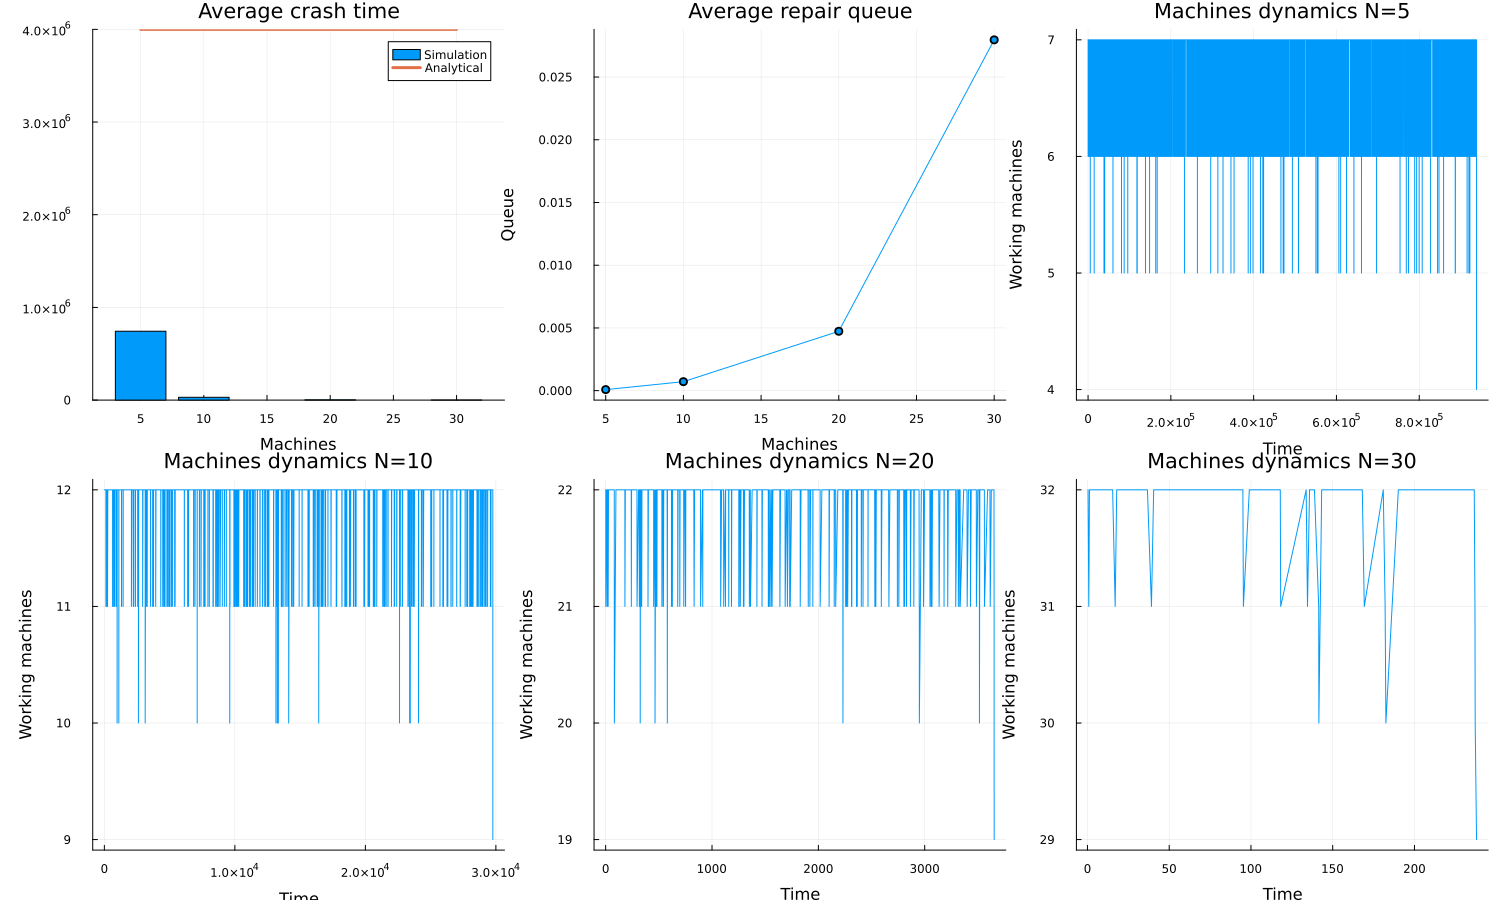

In [8]:
p1 = bar(results.machines, results.crash_time, xlabel="Machines", ylabel="Crash time", title="Average crash time", label="Simulation")
plot!(p1, results.machines, results.analytical, lw=3, label="Analytical")

p2 = plot(results.machines, results.avg_queue, marker=:circle, xlabel="Machines", ylabel="Queue", title="Average repair queue", label=false)

final_plot = plot(p1, p2, plots_list..., layout=(2,3), size=(1500,900))
display(final_plot)
savefig(plotsdir("ross_model_plots.png"))

println("Результаты сохранены в data/ и plots/")

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*